In [47]:
path = "/home/yamane/helixEncoder/helix_encoder/output/result/"

# result name
old = "AUCs--lr=1e-4,dropout=0.1,weight_decay=1e-4,kernel=7,n_layer=3,batch=64,ClassAbyproteinHelix,100e,modifiedModel.txt"
new = "classA_position_reverse.txt"
layernorm = "classA_position_reverse_layerNorm.txt"
concat = "AUCs--lr=1e-4,dropout=0.1,weight_decay=1e-4,kernel=7,n_layer=3,batch=64,ClassAbyproteinHelix,100e,concat.txt"

# read

def open_file(name):
  with open(path + name,"r") as f:
    data_list = f.read().strip().split('\n')
  result = []
  for data in data_list:
    result.append(data.split("\t"))
  valAUC = [float(d[3]) for i,d in enumerate(result) if i != 0]
  trainLoss = [float(d[2]) for i,d in enumerate(result) if i != 0]
  return valAUC,trainLoss

In [48]:
old_valAUC,old_trainLoss = open_file(old)
new_valAUC,new_trainLoss = open_file(new)
layer_valAUC,layer_trainLoss = open_file(layernorm)
con_valAUC,con_trainLoss = open_file(concat)

import numpy as np
layer_pad = [np.nan]*100
for i,v in enumerate(layer_valAUC):
  layer_pad[i] = v

con_pad = [np.nan]*100
for i,v in enumerate(con_valAUC):
  con_pad[i] = v

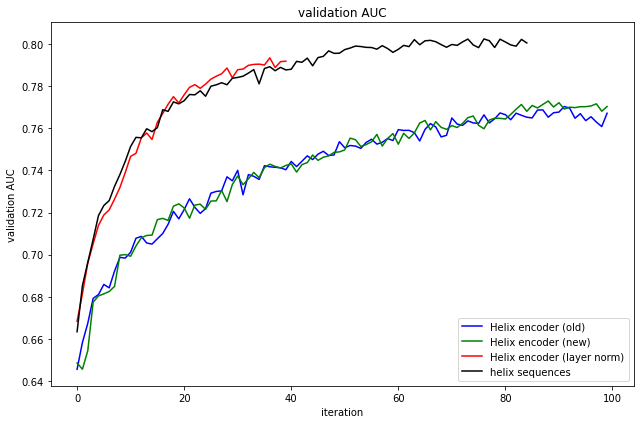

In [49]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize = (9,6))

t = [i for i in range(100)]
c1,c2,c3,c4 = "blue","green","red","black"
l1,l2,l3,l4 = "Helix encoder (old)","Helix encoder (new)","Helix encoder (layer norm)","helix sequences"

ax.set_xlabel('iteration')  # x軸ラベル
ax.set_ylabel('validation AUC')  # y軸ラベル
ax.set_title("validation AUC")


ax.plot(t, old_valAUC, color=c1, label=l1)
ax.plot(t, new_valAUC, color=c2, label=l2)
ax.plot(t, layer_pad, color=c3, label=l3)
ax.plot(t, con_pad, color=c4, label=l4)
ax.legend(loc=0)    
fig.tight_layout()
#fig.savefig("validationAUC.png")  
plt.show()

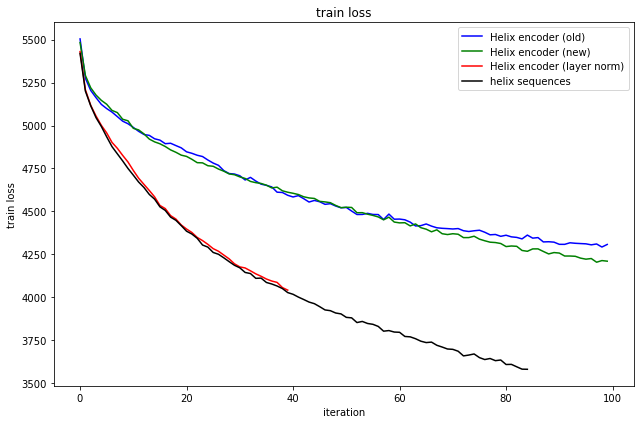

In [50]:
import matplotlib.pyplot as plt

import numpy as np
layer_pad_loss = [np.nan]*100
for i,v in enumerate(layer_trainLoss):
  layer_pad_loss[i] = v

con_pad_loss = [np.nan]*100
for i,v in enumerate(con_trainLoss):
  con_pad_loss[i] = v


fig, ax = plt.subplots(figsize = (9,6))

t = [i for i in range(100)]
c1,c2,c3,c4 = "blue","green","red","black"
l1,l2,l3,l4 = "Helix encoder (old)","Helix encoder (new)","Helix encoder (layer norm)","helix sequences"

ax.set_xlabel('iteration')  # x軸ラベル
ax.set_ylabel('train loss')  # y軸ラベル
ax.set_title("train loss")

ax.plot(t, old_trainLoss, color=c1, label=l1)
ax.plot(t, new_trainLoss, color=c2, label=l2)
ax.plot(t, layer_pad_loss, color=c3, label=l3)
ax.plot(t, con_pad_loss, color=c4, label=l4)
ax.legend(loc=0)    
fig.tight_layout()
#fig.savefig("trainloss.png")    
plt.show()

